# CHURN ANALYSIS

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [63]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [71]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   int64  
 17  Paymen

,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,MonthlyCharges
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.592219,64.761692
std,0.368612,0.499748,0.458110,24.559481,0.491457,30.090047
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000
25%,0.000000,0.000000,0.000000,9.000000,0.000000,35.500000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,70.350000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,89.850000
max,1.000000,1.000000,1.000000,72.000000,1.000000,118.750000


In [77]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [81]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [82]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

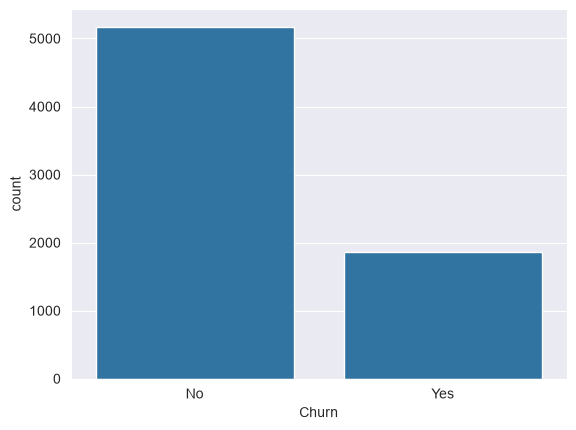

In [74]:
#Is dataset balacnced?
sns.countplot(x="Churn", data=df)
plt.show()

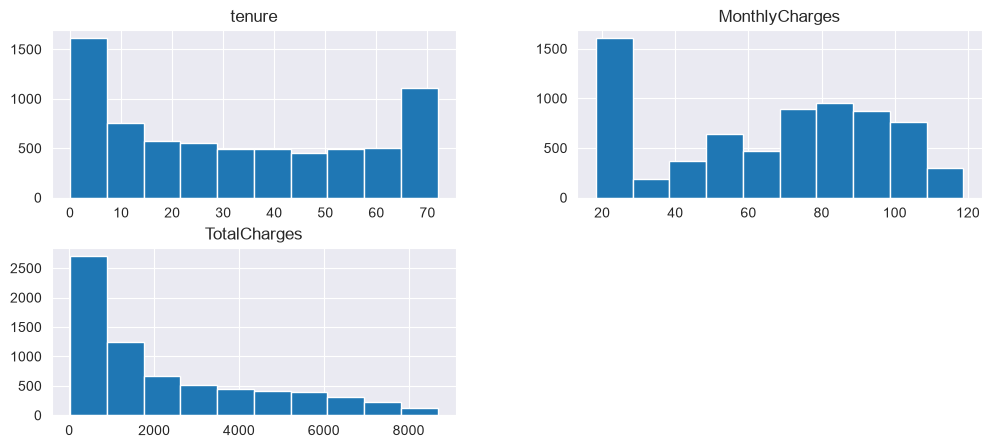

In [14]:
#Numerical Distribution
df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]].hist(figsize=(12, 5))
plt.show()

In [ ]:
#Churn vs Numerical Features

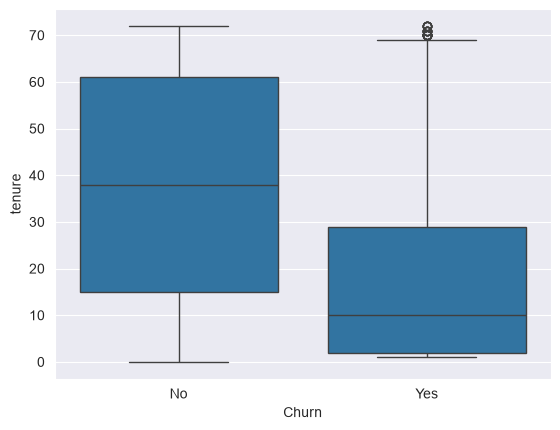

In [75]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

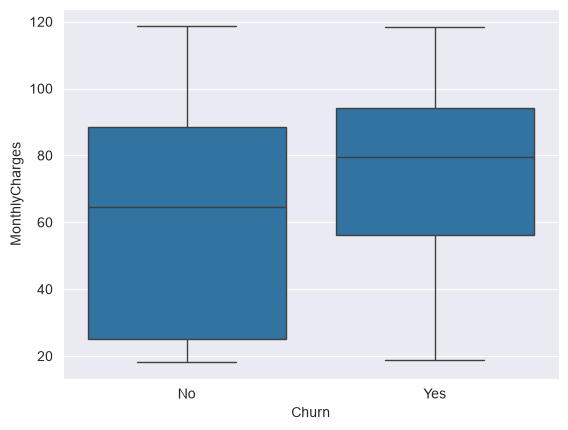

In [18]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

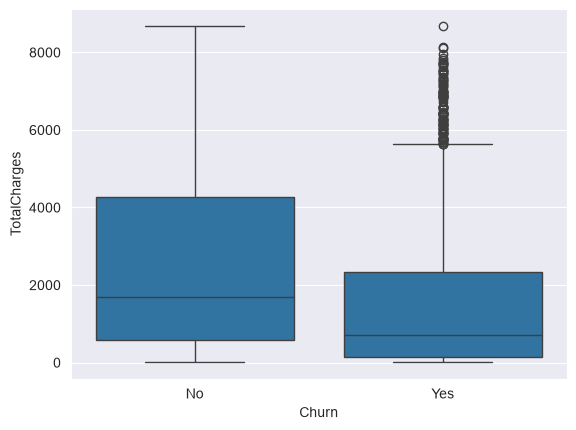

In [19]:
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.show()

In [ ]:
#Categorical Analysis

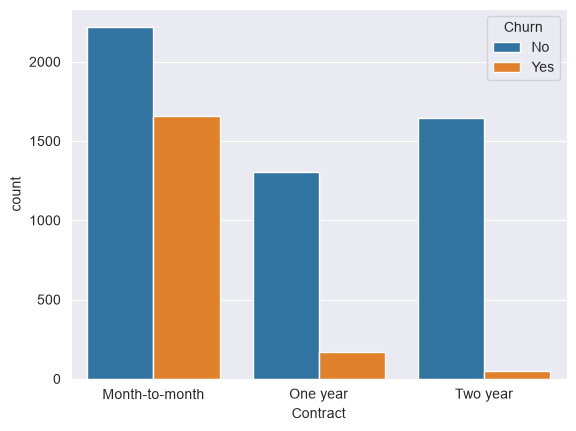

In [20]:
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.show()

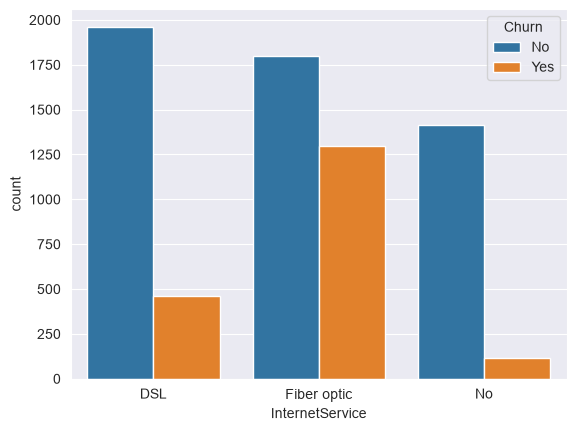

In [21]:
sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.show()

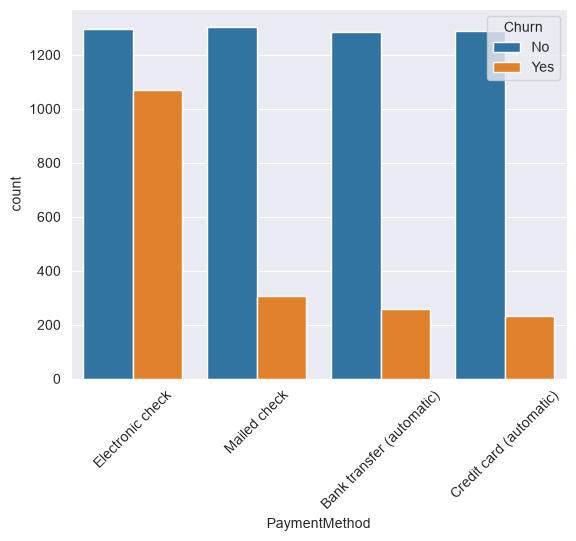

In [22]:
sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)
plt.show()

In [76]:
df['Churn'] = df['Churn'].map({
    "No":0,
    "Yes":1
})

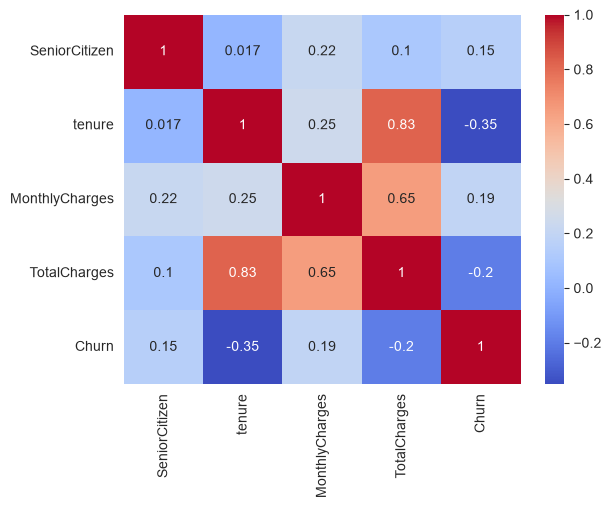

In [25]:
#Correlation
numeric_df = df.select_dtypes(
    include=["int64","float64"]
)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [64]:
print(df["PaperlessBilling"].unique())

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


In [66]:
binary_cols = [
    "Partner",
    "Dependents",
    "PaperlessBilling"
]

for col in binary_cols:
    df[col] = df[col].astype(str).map({
        "No": 0,
        "Yes": 1
    })

print(df[binary_cols].head())

   Partner  Dependents  PaperlessBilling
0        1           0                 1
1        0           0                 0
2        0           0                 1
3        0           0                 0
4        0           0                 1


In [83]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [68]:
df["Contract"].head()

0    Month-to-month
1          One year
2    Month-to-month
3          One year
4    Month-to-month
Name: Contract, dtype: str

In [84]:
X = df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Partner",
    "Dependents",
    "PaperlessBilling"
]]

y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1:",f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7494677075940384
Precision: 0.5239234449760766
Recall: 0.5871313672922251
F1: 0.5537294563843237
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      1036
           1       0.52      0.59      0.55       373

    accuracy                           0.75      1409
   macro avg       0.68      0.70      0.69      1409
weighted avg       0.76      0.75      0.75      1409

[[837 199]
 [154 219]]


In [85]:
from sklearn.linear_model import LogisticRegression
model_1 = LogisticRegression()
model_1.fit(X_train, y_train)
y_pred = model_1.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1:",f1_score(y_test, y_pred))

Accuracy: 0.7977288857345636
Precision: 0.6549295774647887
Recall: 0.49865951742627346
F1: 0.5662100456621004


C:\ai-projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
